<a href="https://colab.research.google.com/github/BhaskarKumarSinha/Ml-Deep-Learning-AI-Projects/blob/main/DeepLearningProject/Creative_AI_Generating_Art_with_Neural_Style_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the pretrained GAN generator from "https://github.com/AshishJangra27/Face-Generator-with-GAN", the gender vector from "https://github.com/AshishJangra27/Gender-Style-Transfer", and the gender classifier from "https://github.com/AshishJangra27/Gender-Classifier". Then, generate 10 variations of an image, transforming it from male to female using the loaded gender vector.

## Setup

### Subtask:
Install necessary libraries and clone the relevant GitHub repositories.


**Reasoning**:
Install the required libraries and clone the repositories.



In [ ]:
!git clone https://github.com/AshishJangra27/Face-Generator-with-GAN.git


Cloning into 'Face-Generator-with-GAN'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 34 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 160.27 MiB | 16.81 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (10/10), done.


##Loading a Generator model which is pretrained

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = keras.models.load_model("Face-Generator-with-GAN/generator_500.h5")

In [ ]:
model.summary()

This code block generates a random noise vector and uses the loaded generator model to produce an image from this noise vector.

- `import numpy as np`: Imports the NumPy library for numerical operations.
- `noise_dim = 100`: Sets the dimension of the noise vector to 100.
- `random_noise = np.random.normal(0, 1, (1, noise_dim))`: Generates a random noise vector of shape (1, 100) using a normal distribution with mean 0 and standard deviation 1. This vector serves as input to the GAN generator.
- `generated_image = model.predict(random_noise)`: Uses the `predict` method of the loaded generator model (`model`) to generate an image from the `random_noise` vector. The output `generated_image` is the generated image data.

In [ ]:
import numpy as np

# Suppose noise_dim = 100 (you’ll need to verify from their code)
noise_dim = 100
# Generate a batch of random noise vectors
random_noise = np.random.normal(0, 1, (1, noise_dim))  # batch_size = 1

# Use generator to produce an image
generated_image = model.predict(random_noise)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


This code block visualizes the generated image using Matplotlib.

- `import matplotlib.pyplot as plt`: Imports the Matplotlib library for plotting.
- `img = generated_image[0]`: Extracts the first (and in this case, only) image from the `generated_image` array.
- `img = (img + 1) / 2`: Converts the pixel values from the range [-1, 1] to [0, 1]. This is a common practice if the GAN generator uses a tanh activation function in the output layer.
- `plt.imshow(img)`: Displays the image using Matplotlib.
- `plt.axis('off')`: Hides the axes for a cleaner image display.
- `plt.show()`: Renders the plot.

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

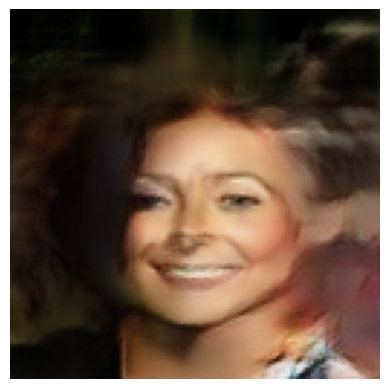

In [ ]:
import matplotlib.pyplot as plt

# Suppose `generated_image` has shape (1, height, width, channels)
img = generated_image[0]

# If pixel values are in range [-1, 1], convert to [0, 1] or [0,255]
img = (img + 1) / 2  # example if they used tanh activation in output
# Or clip: img = np.clip(img, 0, 1)

plt.imshow(img)
plt.axis('off')


###Importing Gender-Style-Transfer vector and Gender-Classifier

In [ ]:
!git clone https://github.com/AshishJangra27/Gender-Style-Transfer.git
!git clone https://github.com/AshishJangra27/Gender-Classifier.git


Cloning into 'Gender-Style-Transfer'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 20 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 18.87 MiB | 14.53 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Cloning into 'Gender-Classifier'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 4.14 MiB | 32.39 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
!pip install tensorflow keras matplotlib numpy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras


###1.Load Generator model

In [ ]:
generator = keras.models.load_model("Face-Generator-with-GAN/generator_500.h5")


### 2. Load gender vector

In [ ]:
gender_vector = np.load("Gender-Style-Transfer/gender_vec.npy")
print("✅ Gender vector loaded with shape:", gender_vector.shape)

✅ Gender vector loaded with shape: (1, 100)


### 3. Generate base latent vector

In [ ]:
latent_dim = generator.input_shape[1]  # read input size from generator
print("Latent dim =", latent_dim)

z = np.random.normal(0, 1, (1, latent_dim))  # base noise vector

Latent dim = 100


### 4. Interpolate male→female

In [ ]:
variations = []
steps = 10

for alpha in np.linspace(-3, 3, steps):
    z_mod = z + alpha * gender_vector  # move in gender direction
    img = generator.predict(z_mod)

    # Normalize if output in [-1,1]
    img = (img + 1) / 2.0
    variations.append(img[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


### 5. Plot results

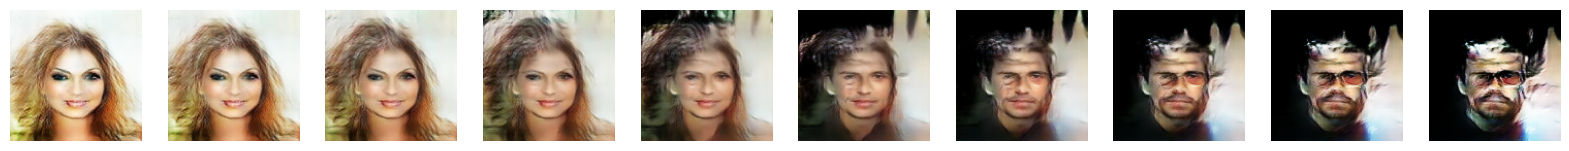

In [ ]:

fig, axes = plt.subplots(1, steps, figsize=(20, 3))
for i in range(steps):
    axes[i].imshow(variations[i])
    axes[i].axis("off")
plt.show()

###Generate variations of an image along the gender vector.

    Parameters:
    - generator: keras model, pretrained GAN generator
    - base_latent: numpy array of shape (1, latent_dim), base noise vector
    - gender_vector: numpy array of shape (1, latent_dim), gender direction vector
    - steps: int, number of variations to generate
    - alpha_range: tuple, min and max values to shift along the gender vector

    Returns:
    - variations: list of numpy arrays, generated images


In [ ]:
def generate_gender_variations(generator, base_latent, gender_vector, steps=10, alpha_range=(-3, 3)):

    variations = []
    for alpha in np.linspace(alpha_range[0], alpha_range[1], steps):
        z_mod = base_latent + alpha * gender_vector
        img = generator.predict(z_mod)
        img = (img + 1) / 2.0  # normalize from [-1,1] → [0,1]
        variations.append(img[0])
    return variations


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


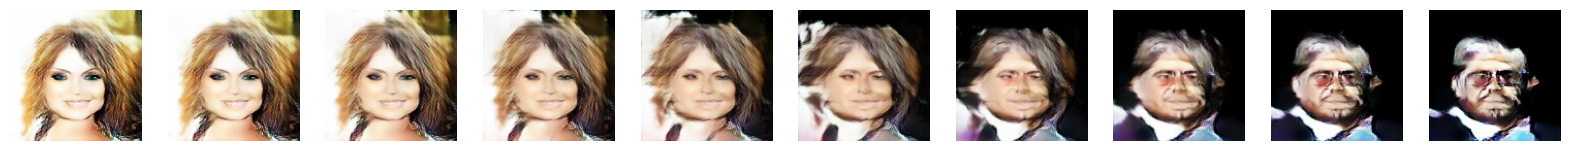

In [ ]:
# Generate a random base latent vector
latent_dim = generator.input_shape[1]
z = np.random.normal(0, 1, (1, latent_dim))

# Generate 10 male→female variations
variations = generate_gender_variations(generator, z, gender_vector, steps=10)

# Plot the results
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i in range(10):
    axes[i].imshow(variations[i])
    axes[i].axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


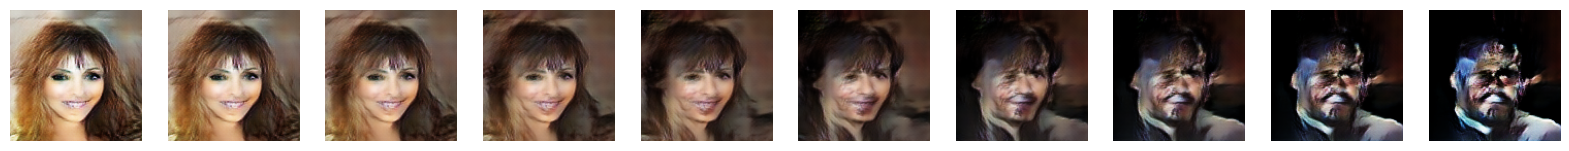

In [ ]:
# Generate a random base latent vector
latent_dim = generator.input_shape[1]
z = np.random.normal(0, 1, (1, latent_dim))

# Generate 10 male→female variations
variations = generate_gender_variations(generator, z, gender_vector, steps=10)

# Plot the results
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i in range(10):
    axes[i].imshow(variations[i])
    axes[i].axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


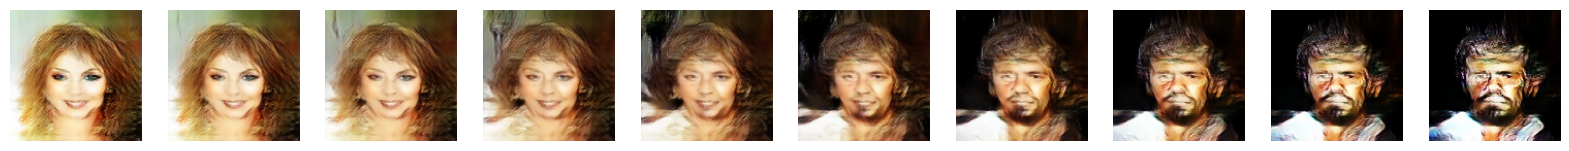

In [ ]:
# Generate a random base latent vector
latent_dim = generator.input_shape[1]
z = np.random.normal(0, 1, (1, latent_dim))

# Generate 10 male→female variations
variations = generate_gender_variations(generator, z, gender_vector, steps=10)

# Plot the results
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i in range(10):
    axes[i].imshow(variations[i])
    axes[i].axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


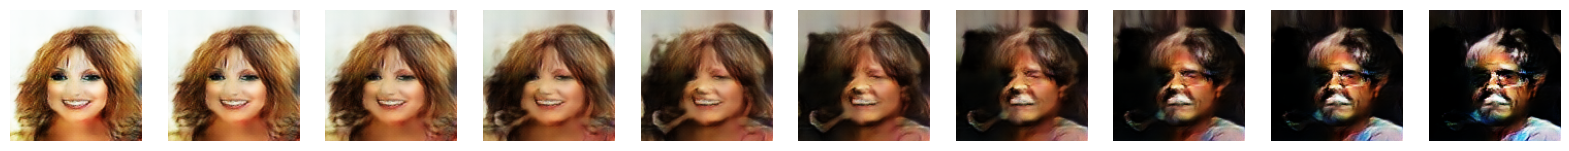

In [ ]:
# Generate a random base latent vector
latent_dim = generator.input_shape[1]
z = np.random.normal(0, 1, (1, latent_dim))

# Generate 10 male→female variations
variations = generate_gender_variations(generator, z, gender_vector, steps=10)

# Plot the results
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i in range(10):
    axes[i].imshow(variations[i])
    axes[i].axis("off")
plt.show()